# A small PINN you can poke at

**The idea in one paragraph.** A physics-informed neural network throws away
the mesh. Instead of unknowns living on mesh cells, the unknown *is* a neural
network $u_\theta(x, t)$ — a smooth, closed-form function of the coordinates,
with the weights $\theta$ as its degrees of freedom. To make it solve a PDE we
never hand it any solution data. We pick a few thousand random points in the
space-time domain, plug the network into the PDE at those points, and measure
how badly the equation fails. That failure is the loss. Minimise it with
gradient descent and the network is squeezed towards a function that satisfies
the equation.

$$
\mathcal{L}(\theta) \;=\;
\underbrace{w_{\mathrm{pde}}\,\big\|\,\mathcal{N}[u_\theta]\,\big\|^2_{\Omega\times(0,T]}}_{\text{the PDE holds inside the domain}}
\;+\;
\underbrace{w_{\mathrm{ic}}\,\big\|\,u_\theta - u_0\,\big\|^2_{t=0}}_{\text{starts from the right state}}
\;+\;
\underbrace{w_{\mathrm{bc}}\,\big\|\,\mathcal{B}[u_\theta]\,\big\|^2_{\partial\Omega}}_{\text{right behaviour at the edges}}
$$

Those three terms are the whole standard recipe. Every one of them is a mean
squared error over a set of points, and the derivatives inside them come from
automatic differentiation — the same machinery that computes gradients for
training, pointed at the *inputs* instead of the weights.

**How that differs from the FEM baseline** in `src/fem/cahn_hilliard.py`:

|  | FEM (DOLFINx) | PINN (this notebook) |
|---|---|---|
| the unknown | coefficients on a mesh | weights of a network |
| space | mesh cells, basis functions | none — evaluated at arbitrary points |
| time | a stepping scheme, one solve per step | $t$ is just another input; the whole space-time block is fit at once |
| how the PDE enters | weak form, assembled into a system | strong-form residual, penalised in a loss |
| how it is solved | Newton + linear solves | gradient descent on the weights |
| accuracy | mesh refinement, provable rates | empirical; no guarantee, and it can fail silently |

That last row is the reason this thesis exists.

---

This notebook is a **sandbox, not thesis code**. It imports nothing from
`src/`, uses only the three standard loss terms — no energy penalty, no
transfer learning, no FEM reference data — and is meant to be edited and
re-run. The final cell maps each piece here onto the real modules.

Two problems, in order:

1. **1D heat equation** (~45 s) — has a closed-form solution, so we can measure
   a true error and confirm the machinery works.
2. **1D Cahn-Hilliard** (~80 s) — the actual thesis PDE, mixed $(c,\mu)$
   formulation. No exact solution to compare to, so we check physical
   properties instead: mass conservation and free-energy decay.

**Kernel:** use the project venv (`.venv`) — the kernel picker is in the top
right of this notebook, or `Ctrl+Shift+P` → *Python: Select Interpreter*. It
needs `torch` (CPU), `matplotlib`, and `ipykernel`; see the README section
"Quick PINN demo" if it is not set up yet.


## Vocabulary

Five terms that appear constantly below and are worth pinning down before any
code, because most PINN papers assume you already have them:

- **Collocation point** — one of the random $(x, t)$ pairs where we check that
  the PDE holds. Loosely the analogue of a quadrature point, except nothing is
  assembled and the points can sit anywhere, in any number, and be resampled at
  will.
- **Residual** — what you get by moving every term of the PDE to one side and
  substituting the network. For the heat equation it is
  $r = \partial_t u_\theta - \alpha\,\partial_{xx} u_\theta$. It is zero exactly
  when the equation is satisfied, so `mean(r**2)` is a natural thing to
  minimise.
- **Soft constraint** — the initial and boundary conditions are *penalties*,
  not hard requirements. The trained network will violate them a little, always.
  (They can be built in exactly — by construction rather than by penalty — which
  is a known improvement, and deliberately not done here.)
- **Full batch** — every training step uses *all* the points at once. Standard
  for problems this small; there is no data loader and no notion of an epoch as
  a pass over data. "Epoch" below just means "one optimiser step".
- **Spectral bias** — networks fit smooth, low-frequency structure long before
  sharp features. This is why thin interfaces (small $\varepsilon$) are hard,
  and it will show up in section 5.


## Setup

Nothing surprising here. The seed makes runs reproducible: change it and re-run
to see how much of the final accuracy is luck of the initialisation — with
PINNs, more than you would like.


In [8]:
import math
import time

import matplotlib.pyplot as plt
import torch
from torch import nn

torch.manual_seed(0)
device = torch.device("cpu")  # this notebook is small on purpose; "cuda" also works

print("torch", torch.__version__, "| device", device)


torch 2.13.0+cpu | device cpu


## 1. Ingredients

Two of them. First the network.

Nothing about it is special — it is a plain fully-connected stack, four hidden
layers of 32 units, about 3300 weights. Two details do matter:

- **`tanh` activations.** The loss contains second derivatives of the network,
  so the activation has to be at least twice differentiable and not flat.
  `ReLU` has zero second derivative everywhere and would give an identically
  zero PDE residual — a PINN with `ReLU` cannot work.
- **Input normalisation, inside `forward`.** The raw inputs get squashed to
  $[-1, 1]$ before the first layer. Because that rescaling is part of the
  autograd graph, derivatives with respect to the *physical* $(x, t)$ still come
  out correctly scaled, with no bookkeeping on our side. Leaving it out is one
  of the most common reasons a PINN on a domain like $t \in [0, 0.05]$ refuses
  to train at all: the network sees inputs of order $10^{-2}$ and can barely
  distinguish them.

**Shape convention for the whole notebook:** a batch of points is a tensor of
shape `(N, 2)` whose columns are `[x, t]`, and every scalar field is kept as a
column of shape `(N, 1)` rather than a flat vector. That is why the code is
full of `[:, 0:1]` instead of `[:, 0]` — it keeps the trailing dimension so
broadcasting never silently produces an `(N, N)` matrix.


In [9]:
class MLP(nn.Module):
    """Fully-connected tanh network with inputs normalised to [-1, 1]."""

    def __init__(self, lower, upper, output_dim, hidden_layers=4, hidden_width=32):
        super().__init__()
        # Buffers, not parameters: saved with the model, but not trained.
        self.register_buffer("lower", torch.tensor(lower, dtype=torch.float32))
        self.register_buffer("upper", torch.tensor(upper, dtype=torch.float32))

        dims = [len(lower)] + [hidden_width] * hidden_layers + [output_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:      # no activation on the output layer
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)

        # Xavier/Glorot: the usual choice for tanh nets, keeps early-layer
        # activations away from the flat tails where gradients vanish.
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, z):
        # z: (N, 2) with columns [x, t] -> normalised to [-1, 1] per column.
        h = 2.0 * (z - self.lower) / (self.upper - self.lower) - 1.0
        return self.net(h)


### The second ingredient: derivatives with respect to the inputs

This is the part that makes a PINN a PINN, and the part worth slowing down for.

Ordinary training differentiates the loss with respect to the **weights**.
Here we also need derivatives of the network output with respect to its
**inputs** — $u_x$, $u_{xx}$, $u_t$ — because those are what the PDE is made
of. PyTorch will do it, with two requirements:

1. the input tensor must carry `requires_grad=True`, so the graph records
   operations back to it;
2. each `grad` call must pass `create_graph=True`, which keeps the derivative
   *itself* a differentiable expression. Without it you get a number and can
   neither differentiate again (no $u_{xx}$) nor backpropagate the loss to the
   weights.

`torch.autograd.grad` wants a scalar, so we pass `grad_outputs=torch.ones_like(y)`
to sum over the batch — since each row's output depends only on its own row's
input, that sum hands back exactly the per-point derivatives, one row each.

The result has the same shape as the input, **one column per coordinate**:

```
du = d(u, z)          # (N, 2)
u_x = du[:, 0:1]      # column 0  <- because z's column 0 is x
u_t = du[:, 1:2]      # column 1  <- because z's column 1 is t
```

These derivatives are *exact* for the network — not finite differences, no
truncation error, no mesh spacing. That is one of the genuinely attractive
properties of the method.


In [10]:
def d(y, z):
    """dy/dz for a scalar-valued column `y`, keeping the graph alive."""
    return torch.autograd.grad(y, z, grad_outputs=torch.ones_like(y), create_graph=True)[0]


def mse(x):
    """Mean squared error against zero — every loss term below is of this form."""
    return torch.mean(x**2)


Before trusting it on a network, try `d` on a function whose derivatives we
know by hand. Take $u(x,t) = \sin(\pi x)\,e^{-t}$, so that
$u_x = \pi\cos(\pi x)e^{-t}$, $u_{xx} = -\pi^2 u$, and $u_t = -u$.

Errors around $10^{-7}$ below are float32 round-off — this is exact
differentiation, not an approximation.


In [11]:
z = torch.rand(5, 2, requires_grad=True)          # 5 random points, columns [x, t]
u = torch.sin(math.pi * z[:, 0:1]) * torch.exp(-z[:, 1:2])

du = d(u, z)                    # (5, 2)
u_x, u_t = du[:, 0:1], du[:, 1:2]
u_xx = d(u_x, z)[:, 0:1]        # differentiating a second time — needs create_graph=True

exact_u_x = math.pi * torch.cos(math.pi * z[:, 0:1]) * torch.exp(-z[:, 1:2])
print(f"max |u_x  - pi cos(pi x) e^-t| : {(u_x - exact_u_x).abs().max().item():.2e}")
print(f"max |u_xx + pi^2 u|            : {(u_xx + math.pi**2 * u).abs().max().item():.2e}")
print(f"max |u_t  + u|                 : {(u_t + u).abs().max().item():.2e}")


max |u_x  - pi cos(pi x) e^-t| : 3.73e-09
max |u_xx + pi^2 u|            : 4.77e-07
max |u_t  + u|                 : 0.00e+00


## 2. The points — a "dataset" with no data

A PINN's training set is just coordinates. Three sets, one per loss term:

| set | where | what is enforced there |
|---|---|---|
| `z_pde` | random, throughout the space-time domain | the PDE residual is zero |
| `z_ic` | a grid along $t = 0$ | the solution equals the initial condition |
| `z_bc` | grids up both edges $x = x_{lo}$ and $x = x_{hi}$ | the boundary condition |

Two choices to notice. Interior points are **uniform random** — a Latin
hypercube or Sobol sequence is the usual upgrade, and resampling them
periodically during training is another. The IC and BC points are on regular
grids instead, so those constraints get even coverage rather than accidental
gaps.

`z_pde` and `z_bc` get `requires_grad_(True)` because we differentiate the
network at those points. `z_ic` does not: the initial-condition term only
compares values.


In [12]:
def sample_points(bounds, n_collocation=4000, n_ic=200, n_bc=200):
    """Interior, t=0, and boundary point sets for bounds = (x_lo, x_hi, t_lo, t_hi)."""
    x_lo, x_hi, t_lo, t_hi = bounds

    # Interior: uniform random over the space-time rectangle.
    x = torch.rand(n_collocation, 1, device=device) * (x_hi - x_lo) + x_lo
    t = torch.rand(n_collocation, 1, device=device) * (t_hi - t_lo) + t_lo
    z_pde = torch.cat([x, t], dim=1).requires_grad_(True)

    # Initial condition: a line of points along t = t_lo.
    x_ic = torch.linspace(x_lo, x_hi, n_ic, device=device).unsqueeze(1)
    z_ic = torch.cat([x_ic, torch.full_like(x_ic, t_lo)], dim=1)

    # Boundaries: two lines of points, up the left and right edges.
    t_bc = torch.linspace(t_lo, t_hi, n_bc, device=device).unsqueeze(1)
    z_bc = torch.cat(
        [
            torch.cat([torch.full_like(t_bc, x_lo), t_bc], dim=1),
            torch.cat([torch.full_like(t_bc, x_hi), t_bc], dim=1),
        ],
        dim=0,
    ).requires_grad_(True)

    return z_pde, z_ic, z_bc


Worth one plot, because seeing the three sets at once makes the method click:
the interior cloud is where the physics is imposed, and the two grids are the
only places the solution is anchored to anything specific.


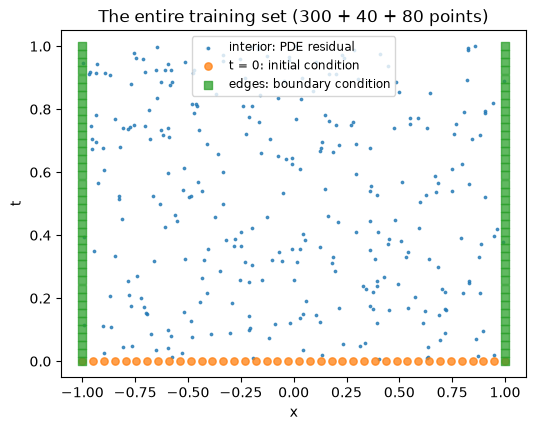

In [13]:
demo = sample_points((-1.0, 1.0, 0.0, 1.0), n_collocation=300, n_ic=40, n_bc=40)
labels = ["interior: PDE residual", "t = 0: initial condition", "edges: boundary condition"]

fig, ax = plt.subplots(figsize=(6, 4.5))
for pts, label, marker, size in zip(demo, labels, [".", "o", "s"], [12, 28, 28]):
    p = pts.detach().cpu()
    ax.scatter(p[:, 0], p[:, 1], s=size, marker=marker, label=label, alpha=0.75)
ax.set(xlabel="x", ylabel="t", title="The entire training set (300 + 40 + 80 points)")
ax.legend(fontsize="small", loc="upper center")
plt.show()


## 3. The training loop

Same shape as any PyTorch loop — forward, loss, `backward()`, step — with two
PINN-specific quirks.

**`loss_fn` is a closure taking no arguments.** Each problem below builds one
that already holds its model and its points, and returns a *dict* of the
separate loss terms. Keeping them separate costs nothing and buys the single
most useful diagnostic in the whole method: which constraint is actually
holding the fit back.

**Adam first, then L-BFGS.** Adam is robust from a random start but converges
slowly on this kind of loss. L-BFGS is a quasi-Newton method that uses
curvature and can polish the result by one or two orders of magnitude, but it
is fragile far from a solution, so it goes second. Nearly every PINN paper
reports this pairing. Watch the jump at the `final` line — it is usually
dramatic.

**Reading the printed table:**

- `total` is the weighted sum, i.e. the number being minimised.
- `ic` normally collapses first — matching a known function on a line is the
  easiest of the three jobs.
- `pde` normally plateaus and becomes the bottleneck. If it stalls while `ic`
  and `bc` are tiny, the network is producing something smooth and
  boundary-respecting that is simply not a solution.
- The Adam trace is **spiky**, not a smooth descent. Full-batch Adam on a
  residual loss just looks like that; don't read a single bad epoch as failure.
- The columns are the **weighted** terms, so they are directly comparable to
  one another — that is the point of weighting them.

You can interrupt a run (the stop button) and still keep the partially trained
model; the loop mutates the model in place.


In [14]:
def train(model, loss_fn, epochs=3000, lr=1e-3, lbfgs_steps=500, log_every=250):
    """Adam, then an L-BFGS polish. `loss_fn()` returns a dict of loss terms."""
    keys = list(loss_fn().keys())
    history = []

    print(f"Adam: {epochs} epochs, lr={lr}")
    print(f"{'epoch':>7} {'total':>12}" + "".join(f"{k:>12}" for k in keys))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    start = time.perf_counter()

    for epoch in range(epochs + 1):
        optimizer.zero_grad(set_to_none=True)
        parts = loss_fn()               # dict of scalar tensors
        loss = sum(parts.values())      # the number we actually minimise
        loss.backward()                 # d(loss)/d(weights) — through the input derivatives
        optimizer.step()

        record = {"epoch": epoch, "total": loss.item()}
        record.update({k: v.item() for k, v in parts.items()})
        history.append(record)
        if epoch % log_every == 0 or epoch == epochs:
            print(f"{epoch:>7} {record['total']:>12.3e}" + "".join(f"{record[k]:>12.3e}" for k in keys))

    print(f"Adam took {time.perf_counter() - start:.1f} s")

    if lbfgs_steps:
        print(f"\nL-BFGS: up to {lbfgs_steps} iterations")
        start = time.perf_counter()
        lbfgs = torch.optim.LBFGS(
            model.parameters(),
            max_iter=lbfgs_steps,
            history_size=50,
            tolerance_grad=1e-9,
            tolerance_change=1e-12,
            line_search_fn="strong_wolfe",
        )

        # L-BFGS re-evaluates the loss several times per step (line search),
        # so it takes a closure rather than a pre-computed loss.
        def closure():
            lbfgs.zero_grad(set_to_none=True)
            loss = sum(loss_fn().values())
            loss.backward()
            return loss

        lbfgs.step(closure)             # this one call runs up to max_iter iterations

        parts = loss_fn()
        record = {"epoch": epochs, "total": sum(parts.values()).item()}
        record.update({k: v.item() for k, v in parts.items()})
        history.append(record)
        print(f"{'final':>7} {record['total']:>12.3e}" + "".join(f"{record[k]:>12.3e}" for k in keys))
        print(f"L-BFGS took {time.perf_counter() - start:.1f} s")

    return history


### Plot helpers

`evaluate_grid` is where the mesh-free part pays off twice over. We can
evaluate the trained network on *any* grid we like after the fact — resolution
is a display choice, not a solver choice — and we get $u_x$ on that grid by
autograd rather than by differencing neighbours. The free-energy diagnostic in
section 5 needs exactly that derivative.

Note `.detach()` on the way out: past this point we are only looking at
numbers, so we drop the graph and stop tracking gradients.


In [15]:
def evaluate_grid(model, bounds, nx=201, nt=101, component=0):
    """Evaluate the network on a regular (x, t) grid. Returns x, t, u, u_x."""
    x_lo, x_hi, t_lo, t_hi = bounds
    x = torch.linspace(x_lo, x_hi, nx, device=device)
    t = torch.linspace(t_lo, t_hi, nt, device=device)
    grid_t, grid_x = torch.meshgrid(t, x, indexing="ij")

    # Flatten the grid into the usual (N, 2) point list, evaluate, reshape back.
    z = torch.stack([grid_x.reshape(-1), grid_t.reshape(-1)], dim=1).requires_grad_(True)
    u = model(z)[:, component : component + 1]      # `component` picks c or mu later
    u_x = d(u, z)[:, 0:1]
    return x, t, u.reshape(nt, nx).detach(), u_x.reshape(nt, nx).detach()


def plot_history(history, title="Loss"):
    fig, ax = plt.subplots(figsize=(6, 4))
    keys = [k for k in history[0] if k != "epoch"]
    for key in keys:
        ax.semilogy([h["epoch"] for h in history], [h[key] for h in history],
                    label=key, lw=2 if key == "total" else 1)
    ax.set(xlabel="Adam epoch", ylabel="loss (weighted)", title=title)
    ax.legend(fontsize="small")
    ax.grid(alpha=0.3)
    plt.show()


def plot_field(x, t, u, bounds, label="u", n_snapshots=4):
    """Left: the whole space-time solution at once. Right: slices at fixed times."""
    x_np, t_np, u_np = x.cpu().numpy(), t.cpu().numpy(), u.cpu().numpy()
    x_lo, x_hi, t_lo, t_hi = bounds

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    im = axes[0].imshow(u_np, origin="lower", aspect="auto",
                        extent=[x_lo, x_hi, t_lo, t_hi], cmap="coolwarm")
    axes[0].set(title=f"PINN prediction {label}(x, t)", xlabel="x", ylabel="t")
    fig.colorbar(im, ax=axes[0])

    for i in torch.linspace(0, len(t_np) - 1, n_snapshots).round().int().tolist():
        axes[1].plot(x_np, u_np[i], label=f"t = {t_np[i]:.3g}")
    axes[1].set(title="Snapshots", xlabel="x", ylabel=label)
    axes[1].legend(fontsize="small")
    axes[1].grid(alpha=0.3)

    fig.tight_layout()
    plt.show()


## 4. Warm-up: the 1D heat equation

$$u_t = \alpha\,u_{xx}, \qquad x \in [-1, 1],\; t \in [0, 1]$$
$$u(x, 0) = \sin(\pi x), \qquad u(\pm 1, t) = 0$$

A single sine hump that decays in place. It is here for one reason: it has the
closed-form solution

$$u(x,t) = e^{-\alpha \pi^2 t}\,\sin(\pi x),$$

so we can report a *true* relative $L^2$ error instead of just "the loss went
down". Never skip that distinction — a small loss means the network is
self-consistent, not that it is right, and the gap between those two is where
PINNs do their worst damage.

The cell below builds the three loss terms. Reading it against the maths:

| line | term |
|---|---|
| `u_t - alpha * u_xx` | the PDE residual, at the interior points |
| `model(z_ic) - sin(pi x)` | how far $t=0$ is from the initial condition |
| `model(z_bc)` | the boundary values themselves, which should be $0$ |

Each is then squared and averaged by `mse`, and scaled by its weight. The
weights `w_ic = w_bc = 10` say the constraints matter ten times as much, per
unit of squared error, as the residual — see the "things to try" list for why
that number is not innocent.


In [16]:
alpha = 0.1
heat_bounds = (-1.0, 1.0, 0.0, 1.0)   # x_lo, x_hi, t_lo, t_hi


def heat_exact(x, t):
    """The analytic solution — used only for scoring, never for training."""
    return torch.exp(-alpha * math.pi**2 * t) * torch.sin(math.pi * x)


def make_heat_loss(model, points, w_pde=1.0, w_ic=10.0, w_bc=10.0):
    """Build the three standard loss terms as a closure over fixed points."""
    z_pde, z_ic, z_bc = points

    def loss_fn():
        # --- PDE residual: u_t - alpha u_xx should be 0 inside the domain
        u = model(z_pde)
        du = d(u, z_pde)
        u_x, u_t = du[:, 0:1], du[:, 1:2]
        u_xx = d(u_x, z_pde)[:, 0:1]
        residual = u_t - alpha * u_xx

        # --- initial condition: u(x, 0) should equal sin(pi x)
        ic_error = model(z_ic) - torch.sin(math.pi * z_ic[:, 0:1])

        # --- boundary condition: u(+-1, t) should equal 0
        bc_error = model(z_bc)

        return {"pde": w_pde * mse(residual),
                "ic": w_ic * mse(ic_error),
                "bc": w_bc * mse(bc_error)}

    return loss_fn


Now train. **This is the cell to fiddle with** — network size, point counts,
loss weights and optimiser budget are all right here as arguments.

About 45 s with these settings. For a quick sanity pass, drop to
`epochs=200, lbfgs_steps=50` (~2 s) — it will be visibly wrong, around 2 %
error, which is itself informative about how much of the accuracy comes from
the last few thousand steps.

Re-running this cell starts from scratch, since it rebuilds the model. To
train the *existing* model further, call `train(heat_model, heat_loss, ...)`
again on its own.


In [17]:
heat_model = MLP(
    lower=(heat_bounds[0], heat_bounds[2]),   # (x_lo, t_lo)
    upper=(heat_bounds[1], heat_bounds[3]),   # (x_hi, t_hi)
    output_dim=1,                             # just u
    hidden_layers=4,
    hidden_width=32,
).to(device)
print(f"{sum(p.numel() for p in heat_model.parameters())} parameters")

heat_points = sample_points(heat_bounds, n_collocation=4000, n_ic=200, n_bc=200)
heat_loss = make_heat_loss(heat_model, heat_points, w_pde=1.0, w_ic=10.0, w_bc=10.0)

heat_history = train(heat_model, heat_loss, epochs=3000, lr=1e-3, lbfgs_steps=500)


3297 parameters
Adam: 3000 epochs, lr=0.001
  epoch        total         pde          ic          bc
      0    1.067e+01   2.871e-01   8.410e+00   1.974e+00
    250    2.086e-01   7.587e-02   9.463e-02   3.812e-02
    500    1.654e-02   1.248e-02   2.368e-03   1.695e-03
    750    3.632e-03   2.734e-03   5.469e-04   3.518e-04
   1000    1.473e-03   1.182e-03   1.914e-04   9.983e-05
   1250    9.701e-04   7.212e-04   1.491e-04   9.983e-05
   1500    1.115e-03   5.353e-04   2.633e-04   3.168e-04
   1750    5.074e-04   4.260e-04   4.375e-05   3.765e-05
   2000    6.563e-04   3.586e-04   1.133e-04   1.844e-04
   2250    3.705e-04   3.199e-04   2.416e-05   2.646e-05
   2500    3.282e-04   2.870e-04   1.789e-05   2.336e-05
   2750    2.954e-04   2.606e-04   1.376e-05   2.102e-05
   3000    3.523e-04   2.397e-04   5.502e-05   5.758e-05
Adam took 44.6 s

L-BFGS: up to 500 iterations
  final    8.892e-06   7.741e-06   2.891e-07   8.617e-07
L-BFGS took 8.3 s


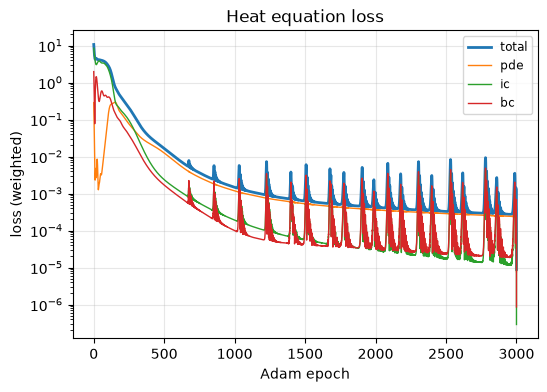

In [18]:
plot_history(heat_history, title="Heat equation loss")


A lot of the *feel* lives in that curve. Typically: everything drops fast for a
few hundred epochs, `ic` and `bc` keep falling, `pde` flattens out and sets the
floor, and the whole trace is jagged. The L-BFGS result is not on this plot —
it is the `final` row of the printed table, usually one to two orders of
magnitude below where Adam left off.

Next, the actual verdict. `evaluate_grid` gives us the network on a 201 × 101
grid; we compare against the analytic solution on the same grid.


Relative L2 error vs. analytic solution: 4.089e-04
Max pointwise error:                     1.051e-03


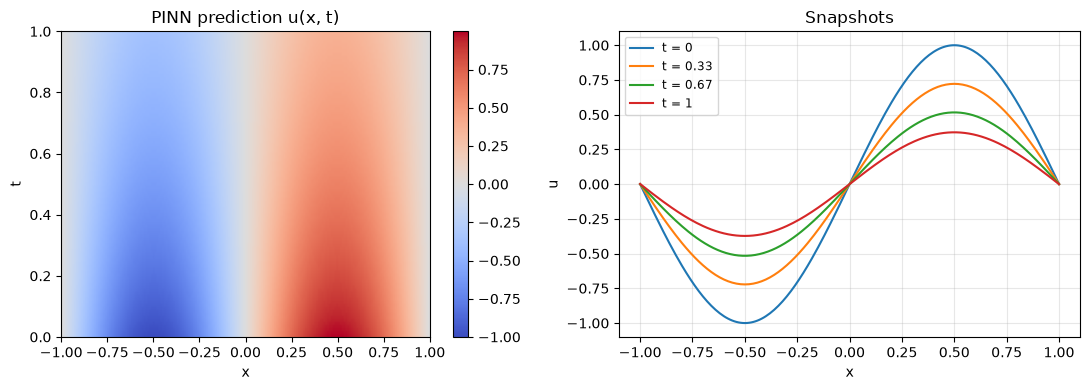

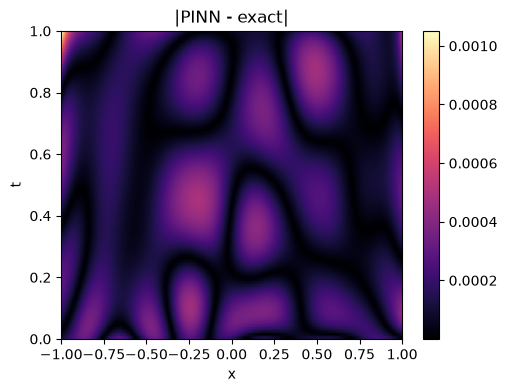

In [19]:
x, t, u, _ = evaluate_grid(heat_model, heat_bounds)

grid_t, grid_x = torch.meshgrid(t, x, indexing="ij")
exact = heat_exact(grid_x, grid_t)
rel_l2 = (torch.linalg.norm(u - exact) / torch.linalg.norm(exact)).item()
print(f"Relative L2 error vs. analytic solution: {rel_l2:.3e}")
print(f"Max pointwise error:                     {(u - exact).abs().max().item():.3e}")

plot_field(x, t, u, heat_bounds, label="u")

fig, ax = plt.subplots(figsize=(5.5, 4))
im = ax.imshow((u - exact).abs().cpu().numpy(), origin="lower", aspect="auto",
               extent=[heat_bounds[0], heat_bounds[1], heat_bounds[2], heat_bounds[3]],
               cmap="magma")
ax.set(title="|PINN - exact|", xlabel="x", ylabel="t")
fig.colorbar(im, ax=ax)
plt.show()


**How to read those three plots.**

The first is the whole solution at once — every $(x,t)$ in one image, computed
without ever stepping through time. A red hump on the right and a blue trough
on the left, both fading upward as $t$ grows: the sine decaying. The snapshots
beside it are horizontal slices of that image.

The error map is the interesting one. Expect roughly $10^{-3}$ overall, and
expect it to be **blotchy** rather than concentrated at the boundaries or
growing with time. That patchiness is characteristic: the error is not a
discretisation error with a rate, it is wherever the optimiser happened to
stop. Refining anything does not reliably shrink it — which is precisely what
makes error control the hard part of the method.

**Things to try** (each is one edit, then re-run the training cell):

- `lbfgs_steps=0` — how much of the accuracy was the second-order phase?
- `w_ic=1.0` — under-weight the initial condition and the network drifts to a
  different solution that also satisfies the PDE, just not yours. The heat
  equation has infinitely many solutions until the IC pins one down, and the
  optimiser is under no obligation to respect a term it is barely paid for.
- `hidden_width=8` — at what point can the network no longer represent it?
- `n_collocation=200` — the residual is only enforced where you sample.
- `alpha=1.0` — much faster decay, sharper time dependence, harder fit.
- change `torch.manual_seed(0)` at the top and re-run everything — the spread
  across seeds is larger than you might expect.


## 5. The real thing: 1D Cahn-Hilliard

Same machinery, pointed at the thesis PDE.

**The physics.** $c(x,t) \in [-1, 1]$ is a phase field: $c = +1$ is one phase,
$c = -1$ the other, and the thin region in between is an interface. The free
energy

$$E(t) \;=\; \int \underbrace{\tfrac{1}{4}(c^2-1)^2}_{\text{double well}} \;+\; \underbrace{\tfrac{\varepsilon^2}{2}|c_x|^2}_{\text{interface cost}}\,dx$$

is what drives everything. The double well pushes $c$ towards $\pm 1$ and
punishes intermediate values; the gradient term punishes sharp transitions.
Their competition sets the interface width, which is what $\varepsilon$
controls. Cahn-Hilliard is the gradient flow that walks downhill in $E$ while
conserving $\int c\,dx$ — a mixture separating into phases without any material
appearing or disappearing.

**The equation, and why it is written as two.** In its natural form it is
fourth order in space:
$c_t = M\,\nabla^2(c^3 - c - \varepsilon^2 c_{xx})$. Instead we split it, using
the chemical potential $\mu$ as a second unknown:

$$c_t = M\,\mu_{xx}, \qquad \mu = c^3 - c - \varepsilon^2 c_{xx}$$
$$c_x = \mu_x = 0 \;\text{ at } x = 0, 1, \qquad c(x, 0) = \tfrac{1}{2}\cos(2\pi x)$$

Now nothing above second order appears, at the cost of a network with **two
outputs**. That is the same mixed formulation the DOLFINx solver in
`src/fem/cahn_hilliard.py` uses, and for the same reason — worth keeping the
two solvers structurally comparable for RQ3. For a PINN there is a second
motive: each extra derivative is another `create_graph` pass, so the
fourth-order form is both slower and numerically nastier.

**What is different from the heat section, concretely:**

- Two residuals rather than one, summed into a single `pde` term.
- Only $c$ gets an initial condition; $\mu$ is pinned by the second equation
  alone, and asking for a $\mu$ initial condition would over-constrain it.
- The boundary conditions are **Neumann** ($c_x = \mu_x = 0$, no flux through
  the walls, which is what conserves mass), so the BC term differentiates the
  network at the boundary points — hence `requires_grad_` on `z_bc`.
- `w_ic = 100`, not 10. The time window is short, so $c_t$ carries a factor of
  roughly $1/t_{\text{final}} = 20$ and the residual is numerically large next
  to an $O(1)$ initial-condition error. Without the reweighting the optimiser
  cheerfully ignores the IC and converges to a flat, PDE-satisfying, wrong
  answer — $c \equiv \text{const}$ is an exact steady solution, and a very
  attractive place for gradient descent to fall into.

The configuration is deliberately gentle: one smooth interface pair,
$\varepsilon = 0.05$, a short window. Gentle enough that the standard losses
already give a sane answer — that is the *starting point* for the thesis
question, not a counterexample to it. Section 6 is about breaking it.


In [20]:
epsilon = 0.05      # interface width
mobility = 1.0      # M
ch_bounds = (0.0, 1.0, 0.0, 0.05)   # x in [0, 1], t in [0, 0.05]


def ch_initial_condition(x):
    return 0.5 * torch.cos(2.0 * math.pi * x)


def make_ch_loss(model, points, w_pde=1.0, w_ic=100.0, w_bc=10.0):
    """Standard PDE + IC + BC terms for the mixed (c, mu) formulation."""
    z_pde, z_ic, z_bc = points

    def fields(z):
        """Unpack the two network outputs and the derivatives both terms need."""
        out = model(z)
        c, mu = out[:, 0:1], out[:, 1:2]
        dc = d(c, z)
        c_x, c_t = dc[:, 0:1], dc[:, 1:2]
        mu_x = d(mu, z)[:, 0:1]
        return c, mu, c_x, c_t, mu_x

    def loss_fn():
        # --- the two coupled residuals
        c, mu, c_x, c_t, mu_x = fields(z_pde)
        c_xx = d(c_x, z_pde)[:, 0:1]
        mu_xx = d(mu_x, z_pde)[:, 0:1]
        residual_c = c_t - mobility * mu_xx                        # c_t = M mu_xx
        residual_mu = mu - (c**3 - c) + epsilon**2 * c_xx          # mu = c^3 - c - eps^2 c_xx

        # --- initial condition on c only; mu is determined by the second equation
        ic_error = model(z_ic)[:, 0:1] - ch_initial_condition(z_ic[:, 0:1])

        # --- no-flux boundaries: both fields have zero slope at the walls
        _, _, c_x_b, _, mu_x_b = fields(z_bc)

        return {"pde": w_pde * (mse(residual_c) + mse(residual_mu)),
                "ic": w_ic * mse(ic_error),
                "bc": w_bc * (mse(c_x_b) + mse(mu_x_b))}

    return loss_fn


Training is identical to before — that is the point of having factored `train`
out. The only visible differences are `output_dim=2` and the longer runtime
(~80 s), which comes from the extra derivatives, not from more epochs.


In [21]:
ch_model = MLP(
    lower=(ch_bounds[0], ch_bounds[2]),
    upper=(ch_bounds[1], ch_bounds[3]),
    output_dim=2,                             # c and mu
    hidden_layers=4,
    hidden_width=32,
).to(device)
print(f"{sum(p.numel() for p in ch_model.parameters())} parameters")

ch_points = sample_points(ch_bounds, n_collocation=4000, n_ic=200, n_bc=200)
ch_loss = make_ch_loss(ch_model, ch_points, w_pde=1.0, w_ic=100.0, w_bc=10.0)

ch_history = train(ch_model, ch_loss, epochs=3000, lr=1e-3, lbfgs_steps=500)


3330 parameters
Adam: 3000 epochs, lr=0.001
  epoch        total         pde          ic          bc
      0    2.035e+02   1.743e+02   2.638e+01   2.753e+00
    250    9.511e+00   2.122e-01   8.581e+00   7.177e-01
    500    5.453e-01   1.243e-01   3.558e-01   6.521e-02
    750    1.511e-01   8.574e-02   4.247e-02   2.291e-02
   1000    1.067e-01   7.709e-02   1.617e-02   1.347e-02
   1250    9.320e-02   7.217e-02   1.243e-02   8.603e-03
   1500    8.569e-02   6.881e-02   1.014e-02   6.741e-03
   1750    8.231e-02   6.843e-02   8.243e-03   5.635e-03
   2000    7.559e-02   6.423e-02   6.504e-03   4.860e-03
   2250    7.122e-02   6.218e-02   4.892e-03   4.155e-03
   2500    6.711e-02   6.015e-02   3.433e-03   3.535e-03
   2750    6.359e-02   5.836e-02   2.259e-03   2.966e-03
   3000    6.065e-02   5.676e-02   1.404e-03   2.484e-03
Adam took 69.0 s

L-BFGS: up to 500 iterations
  final    1.221e-02   1.205e-02   5.440e-05   1.124e-04
L-BFGS took 11.3 s


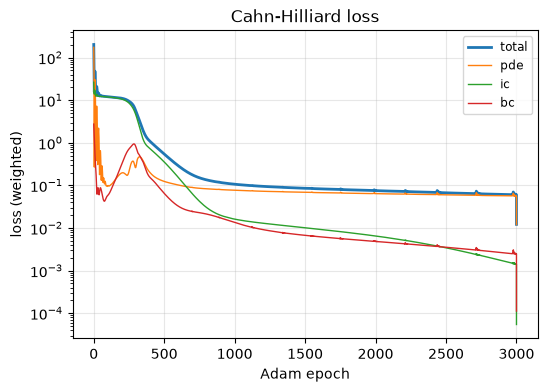

In [22]:
plot_history(ch_history, title="Cahn-Hilliard loss")


### Diagnostics: mass and free energy

There is no analytic solution here, so "is it right?" has to be asked
differently. We check the two properties the exact solution provably has — the
same two the FEM solver logs to `cahn_hilliard_diagnostics.csv`, which is what
makes the comparison in RQ1 and RQ3 possible at all:

- **Mass** $\int c\,dx$ is conserved exactly, for all time.
- **Free energy** $E(t)$ decreases monotonically — never increases, not even
  slightly. Cahn-Hilliard is a gradient flow; going uphill in $E$ is not a
  small numerical blemish, it is physically impossible.

Both are integrals over $x$ at each time, done here by the trapezoid rule on
the evaluation grid, with $c_x$ supplied by autograd. Nothing in the training
loss knew about either quantity — that is what makes them an honest test, and
what the energy penalty in `src/pinn/losses.py` will eventually change.


Mass drift |m(t) - m(0)|_max: 8.657e-05   (exact: 0)
Free energy E(0) -> E(T):     0.1996 -> 0.1163
Energy increases on 0/100 intervals   (exact: 0)


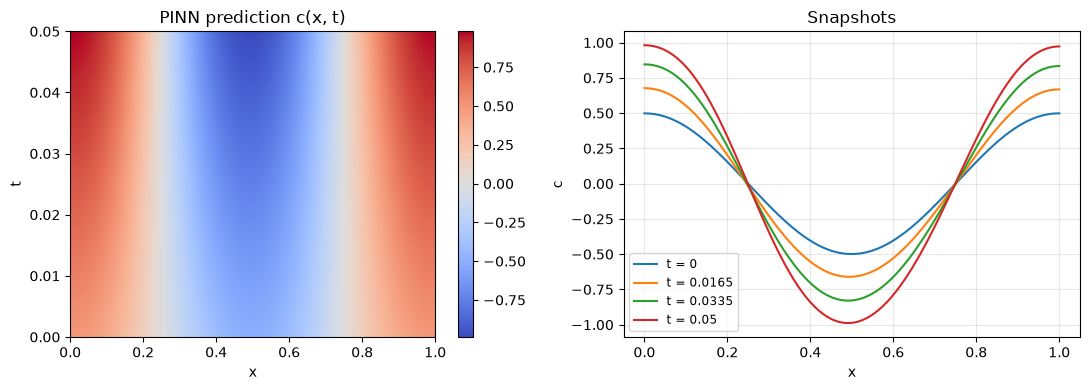

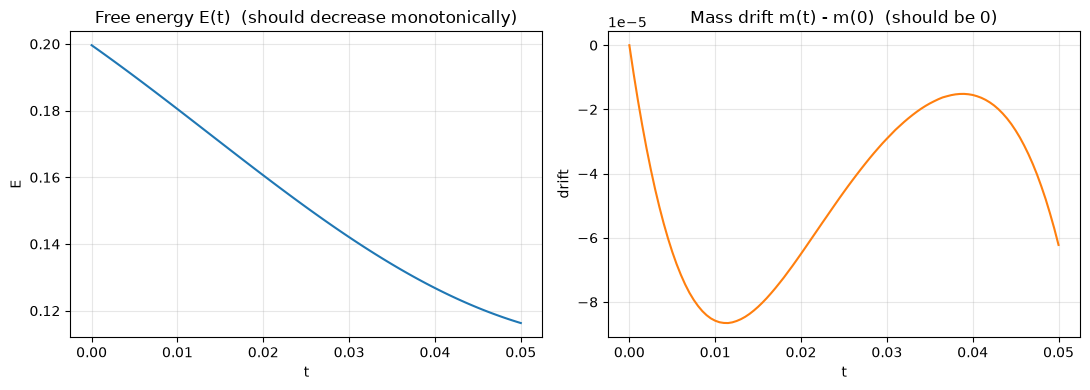

In [23]:
x, t, c, c_x = evaluate_grid(ch_model, ch_bounds, component=0)   # component 0 = c
dx = (ch_bounds[1] - ch_bounds[0]) / (x.numel() - 1)

mass = torch.trapezoid(c, dx=dx, dim=1)                          # integrate over x, per time
energy_density = 0.25 * (c**2 - 1.0) ** 2 + 0.5 * epsilon**2 * c_x**2
energy = torch.trapezoid(energy_density, dx=dx, dim=1)

increases = (energy.diff() > 0).sum().item()
print(f"Mass drift |m(t) - m(0)|_max: {(mass - mass[0]).abs().max().item():.3e}   (exact: 0)")
print(f"Free energy E(0) -> E(T):     {energy[0].item():.4f} -> {energy[-1].item():.4f}")
print(f"Energy increases on {increases}/{energy.numel() - 1} intervals   (exact: 0)")

plot_field(x, t, c, ch_bounds, label="c")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t.cpu(), energy.cpu(), color="tab:blue")
axes[0].set(title="Free energy E(t)  (should decrease monotonically)", xlabel="t", ylabel="E")
axes[1].plot(t.cpu(), (mass - mass[0]).cpu(), color="tab:orange")
axes[1].set(title="Mass drift m(t) - m(0)  (should be 0)", xlabel="t", ylabel="drift")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


**What you should see.** The snapshots start as the $\tfrac12\cos(2\pi x)$ hump
and steepen towards $\pm 1$, with the crossings staying put at $x = 0.25$ and
$x = 0.75$: the two phases separating, interfaces forming where they started.
The energy curve falls smoothly by roughly a factor of two, and mass drift sits
around $10^{-4}$ — small, but *not* zero, and nothing in the training will ever
make it zero. Compare that against the FEM run's CSV, where mass is conserved
to solver tolerance by construction.

If your energy curve has visible upward wiggles, the run is under-trained
rather than broken. Which brings us to the point of the whole exercise.


## 6. How to make it fail — which is the point

On the gentle configuration above, the baseline behaves. The thesis question
only becomes visible when you push it, so push it. Each of these is a one-line
edit followed by a re-run of section 5:

- **Under-train it.** `epochs=200, lbfgs_steps=50`. The energy curve stops
  being monotone almost immediately — often increasing on a third of the time
  intervals. The network is producing a field that is *not* a Cahn-Hilliard
  trajectory, and nothing in the standard loss objects, because no term in it
  has ever heard of energy.
- **Shrink `epsilon`** to 0.02, then 0.01. Thin interfaces are a
  high-frequency feature, and spectral bias means the network reaches for them
  last. Watch the `pde` term stall.
- **Stretch the window:** `ch_bounds = (0.0, 1.0, 0.0, 0.5)`. Long horizons are
  the classic PINN failure mode — the fit degrades from the far end backwards,
  because early times are anchored by the IC and late times by nothing at all.
  This is the motivation for RQ2's time-window transfer learning: solve
  $[0, T_1]$, then warm-start $[T_1, T_2]$ from those weights.
- **Roughen the initial condition** — something like
  `0.05 * torch.randn_like(x)` around a mean — for real spinodal decomposition
  instead of one tidy interface pair. Note this also makes the IC non-smooth,
  which is hard for a different reason.

When mass drifts and energy climbs, that is the gap an energy-stability penalty
is meant to close, and the reason RQ1 is worth asking. The penalty's job is to
add a fourth loss term that makes $dE/dt > 0$ expensive, so the network cannot
buy a lower residual by producing a physically impossible trajectory.


## 7. Mapping back to the thesis code

| here | there |
|---|---|
| `MLP` | `src/pinn/model.py` — `PINN` |
| the `pde` / `ic` / `bc` terms inside `make_*_loss` | `src/pinn/losses.py` — `pde_residual_loss`, `ic_bc_loss` |
| *(deliberately absent)* | `src/pinn/losses.py` — `energy_stability_loss` |
| `train()` | `src/pinn/train.py` — plus checkpointing, a CLI, and Colab/GPU concerns |
| the mass / energy cell | `src/common/metrics.py` — `free_energy`, `mass_conservation_error` |

What is missing here on purpose, and belongs in the real modules: the energy
penalty itself, transfer learning across time windows, 2D (the FEM baseline is
on a unit square — this notebook is 1D so it stays laptop-sized), comparison
against the FEM reference, and checkpointing, which matters because Colab
sessions disconnect mid-run.

To keep a figure, save it explicitly — nothing here writes to disk:

```python
from pathlib import Path
Path("../results/pinn_demo").mkdir(parents=True, exist_ok=True)
plt.gcf().savefig("../results/pinn_demo/ch_diagnostics.png", dpi=130)
```
